# Mandat no. 3 : Simulation Monte-Carlo

In [ ]:
# Simulations Monte-Carlo
import numpy as np
import matplotlib.pyplot as plt
import math


In [ ]:
class exponentiel_distribution:

    def __init__(self, λ):
        self.λ = λ

    def f(self, x):
        return self.λ * np.exp(-self.λ * x)

    def E(self):
        return 1 / self.λ
    
    def V(self):
        return 1 / self.λ**2

In [ ]:
class poisson_distribution:

    def __init__(self, λ):
        self.λ = λ

    def f(self, x, T):
        return (np.exp(-self.λ*T)*(self.λ*T)**x) / math.factorial(x)
    
    def E(self, T):
        return self.λ*T
    
    def V(self, T):
        return self.λ*T

In [ ]:
class normal_distribution:

    def __init__(self, o, u):
        self.o = o
        self.u = u

    def f(self, x):
        a = -(x-self.u)**2 / (2*self.o**2)
        return (1 / (self.o*np.sqrt(2*np.pi))) * np.exp(a)

## Simulations de connection avec différent taux moyen d'arrivées λ
Les données $\sigma$ = 50.12 et $\mu$ = 280.58 ont été récupéré au mandat no. 2 


Les simulations auront 10 000 connections où l'on calculera les joueurs présents sur 300 minutes de temps total.

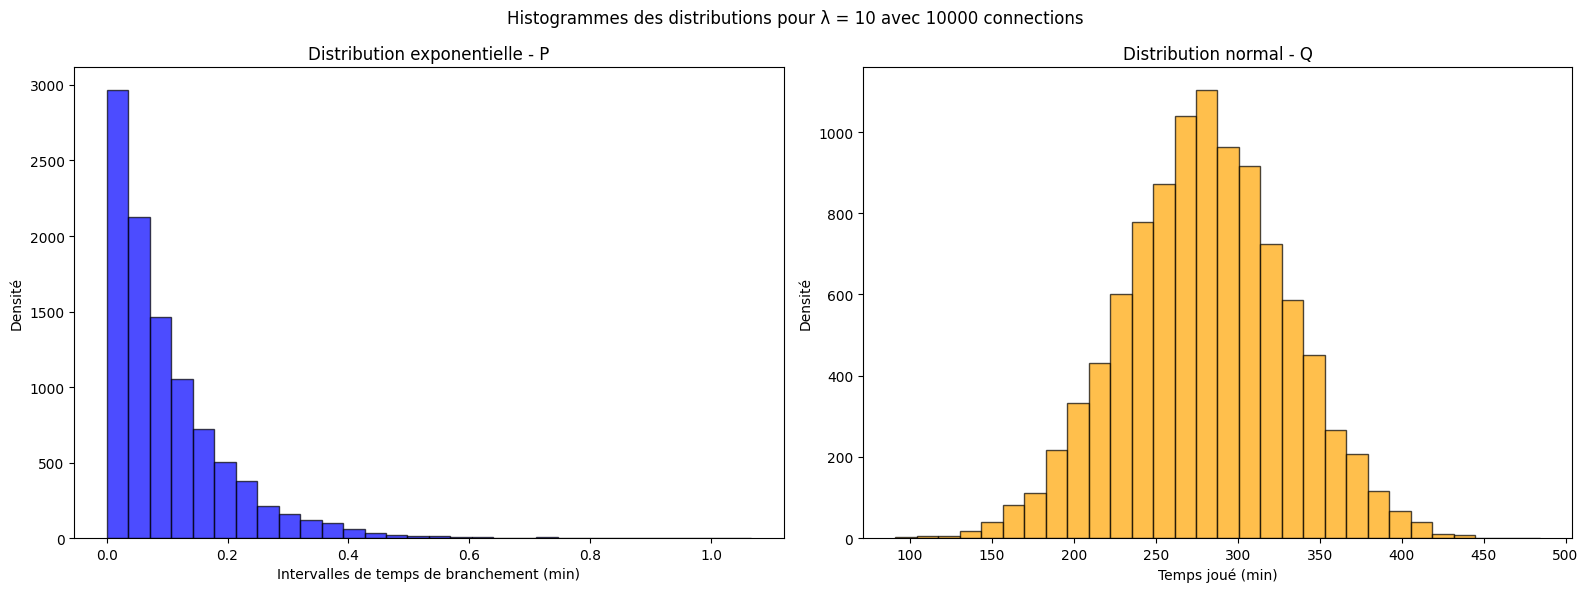

Nombre de joueurs présents pour 300 minutes : 3461


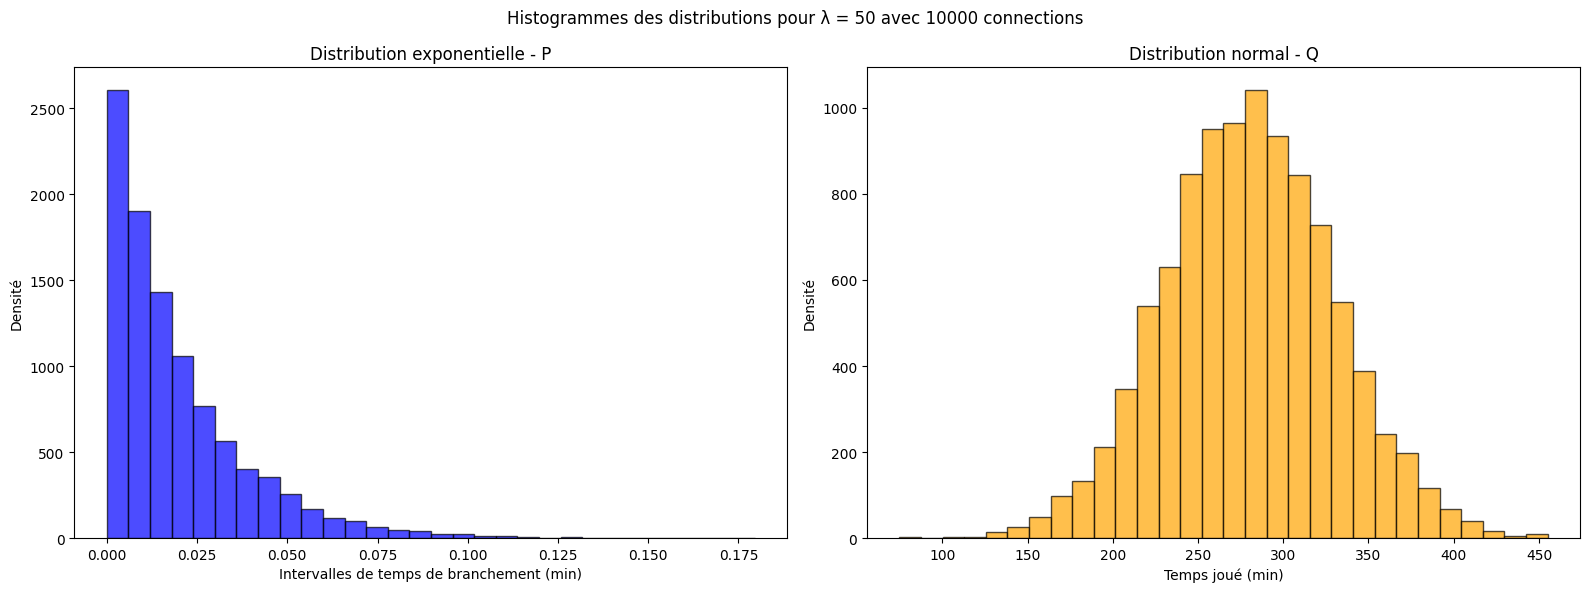

Nombre de joueurs présents pour 300 minutes : 3424


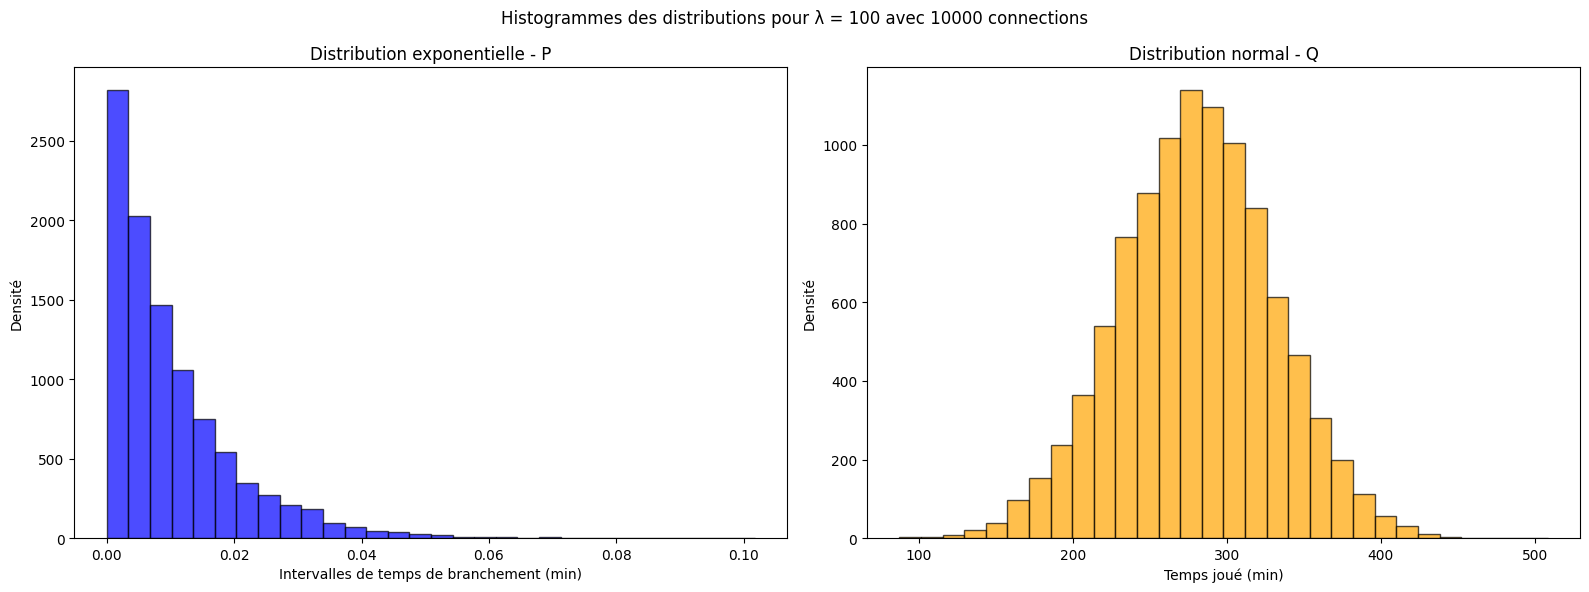

Nombre de joueurs présents pour 300 minutes : 3469


In [67]:
def sim(λ, t):
    N = 10_000
    
    P = np.random.exponential(1/λ, N) # intervalles
    P = P[P <= t] # instants de branchement

    u = 280.58
    o = 50.12
    Q = np.random.normal(u, o, N) # temps joué

    R = P + Q # temps joué fini
    J = np.sum((P <= t) & (R >=t)) # joueurs présents

    plt.figure(figsize=(16, 6))
    plt.subplot(1, 2, 1)
    plt.hist(P, bins=30, alpha=0.7, color='blue', edgecolor='black')
    plt.title(f'Distribution exponentielle - P')
    plt.xlabel("Intervalles de temps de branchement (min)")
    plt.ylabel("Densité")
    plt.subplot(1, 2, 2)
    plt.hist(Q, bins=30, alpha=0.7, color='orange', edgecolor='black')
    plt.title(f'Distribution normal - Q')
    plt.xlabel("Temps joué (min)")
    plt.ylabel("Densité")
    plt.suptitle(f'Histogrammes des distributions pour λ = {λ} avec {N} connections')
    plt.tight_layout()
    plt.show()

    print(f'Nombre de joueurs présents pour {t} minutes : {J}')

λs = [10, 50, 100] # branchements
t = 300 # En minute

sim(λs[0], t)
sim(λs[1], t)
sim(λs[2], t)

